# **HW2**

This notebook converts any given Quran text into a readible one with the aid of python's RegEx according to [this paper](https://ieeexplore.ieee.org/document/4781716) while maintaining Quran's recitation rules.
recitation rules.

**By:**

Wafaa Ashraf Salah-Eldin  201600113

Abdelrahman ElAraby       201700556

Ahmed ElGabry             201701100

In [13]:
#We'll choose AlBaqara [285]. However, our model can be generalized for any arbitary Quran aya
aya = "آمَنَ الرَّسُولُ بِمَا أُنْزِلَ إِلَيْهِ مِنْ رَبِّهِ وَالْمُؤْمِنُونَ كُلٌّ آمَنَ بِاللَّهِ وَمَلَائِكَتِهِ وَكُتُبِهِ وَرُسُلِهِ لَا نُفَرِّقُ بَيْنَ أَحَدٍ مِنْ رُسُلِهِ وَقَالُوا سَمِعْنَا وَأَطَعْنَا غُفْرَانَكَ رَبَّنَا وَإِلَيْكَ الْمَصِيرُ"

# **Part 1. Setting the Phoneme Set, Phonetic Dictionary, and Classes Sets**

We have used the same phoneme set in (M. Ali, et. al) as per the following table
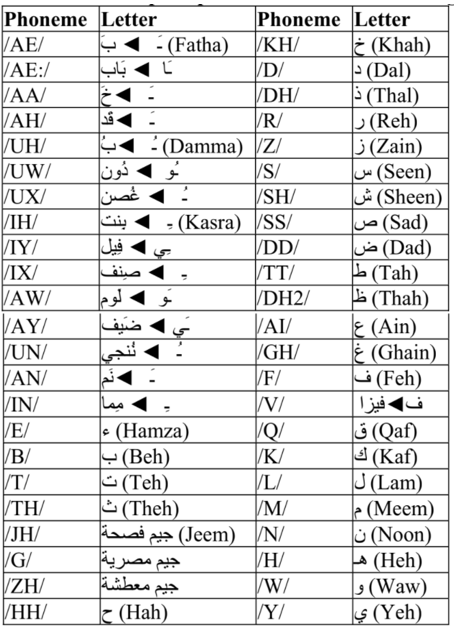

In [14]:
''' First, Arabic Alphabet '''
#We needed to pre-defin the vars in English because mixing Arabic with English letters was very messy in the regex (left vs. right directions) so we will write the regex in English
Alef='ا' #/A/
Alef_Hamza = 'أ' #E
Alef_Mad='آ' #/AE:/
Hamza = 'ء' #/E/'
Beh='ب' #/B/
Teh='ت' #/T/
Theh='ث' #/TH/
Jeem='ج' #/JH/ 
Hah='ح' #/HH/
Khah='خ' #/KH/
Dal='د' #/D/
Thal='ذ' #/DH/
Reh='ر' #/R/
Zain='ز' #/Z/
Seen='س' #/S/
Sheen='ش' #/SH/
Sad='ص' #/SS/
Dad='ض' #/DD/
Tah='ط' #/TT/
Zah='ظ'#/DH2/
Ain='ع'#/AI/
Ghain='غ'#/GH/
Feh='ف'#/F/ we also didn't need the v for quran
Qaf='ق' #/Q/
Kaf='ك' #/K/
Lam='ل' #/L/
Mem='م' #/M/
Noon='ن' #/N/
Heh='ه' #/H/
Wow='و' #/W/
Yeh='ي' #/Y/

''' Second, Arabic Formation (Tashkeel)'''
#As M. Ali, et. al. indicated, there're several types of fath so we followed the phonemes mentioned in the paper
Fatha='a' #/AE/
Fatha_2='b'  #/AH/
Fatha_3='c'  #/AA/
Fatha_4='d' #/AA:/
Fatha_5='e' #/AH:/
Fatha_6='f' #/AW/
Fatha_7='g' #/AY/
Damma='ُ' #/UH/
Damma_2='=' #/UX/
Kasra='ِ'  #/IH/
Kasra_2='-' #/IX/
Shadda='ّ'
double_fatha='ً'
double_damma='ٌ'
double_kasra='ٍ'

'''Third, Map the Quran Letters to M. Ali, et. al's phonemes'''
letter_to_phoneme = {'ا':'/A/','أ':'E','آ':'/AE:/','ء':'/E/','ب':'/B','ت':'/T/',
                     'ث':'/TH/','ج':'/JH/','ح':'/HH/','خ':'/KH/','/د/':'/D/',
                     '/ذ/':'/DH/', 'ر':'/R/','ز':'/Z/','س':'/S/','ش':'/SH/',
                     'ص':'/SS/','ض':'/DD/','ط':'/TT/','ظ':'/DH2/','ع':'/AI/',
                     'غ':'/GH/','ف':'/F/','ق':'/Q/','ك':'/K/','ل':'/L/','م':'/M/',
                     'ن':'/N/', 'ه':'/H/','و':'/W/','ي':'/Y/','ى':'/A/', 'َ':'/AE/',
                     'ُ':'/UH/', 'ِ':'/IH/', 'a':'AE:', 'b':'/AH/',  'c':'/AA/',
                     'd':'/AA:/','e':'/AH:/', 'f':'/AW/', 'g':'/AY/', 'ْ':'',
                     'ئ':'EIH', 'ؤ':'EUH','إ':'E', 'ة':'T','=':'/UX/','-':'/IX/'}

'''Fourth, Set the classes as per M. Ali, et. al's class definition'''
#We don't really know how valid are these classes but we took them exactly as they are and what they include from the paper

L = 'بتثجحخدذرزسشصضطظعغفقكلمنه'   # All Arabic consonants (Beh, Teh, Theh, Jeem, Hah, Khah, Dal,Thal, Reh, Zain, Seen Sheen, Sad, Dad, Tah, Zah, Ain, Ghain, Feh, Qaf, Kaf, Lam, Mem, Noon, Heh)
D = 'ًٌٍَُِّْ'                       # Diacritic marks (Fathatan, Dammatan, Kasratan Fatha, Damma, Kasra, Shadda, and Sukun). We've wrote them all but Google colab is not showing it properly
S = 'BOS'                     # Word start                     
T = 'EOS'                     # Word end        
SH = 'تثدذرزسشصضطظلن'         # Shamsi Letters (Teh, Theh, Dal, Thal, Reh, Zain, Seen Sheen, Sad, Dad, Tah, Zah, Lam, and Noon).
V = 'َُِّ'                       # Vowels (Fatha, Damma, Kasra, and Shadda). Also wrote them all but they're not showing
VA = 'َُِ'                      # Vowels without Shadda (Fatha, Damma, and Kasra).
P = 'وبفكل'                   # Prefix letters (Waw, Beh, Feh, Kaf, and Lam).
E = 'طصظظ'                 # Emphatic letters (Tah, Sad, Dad, and Zah).
PH = 'قغخر'                  # Pharyngeal letters (Qaf, Ghain, Khah, and Reh).


# **Part 2. Mapping Paper Class Rules Into Regexes to be Substituted**

The paper contains a set of groups, each has its own rules. Here, we map each group into its own rules. Group 1: Vowels, Group 2: Tanween, Group 3: Semi Vowels. Group 4: Letter Lam. Group 5 for constonants

In [15]:
import re
def rule_to_regex(word):
  # Group_1
  word = re.sub(Fatha+'('+Wow+'(['+L+']|['+T+"]))",Fatha_6+r'\1',word)
  word = re.sub('(['+E+'])'+Fatha+Alef,r'\1'+Fatha_5,word)
  word = re.sub('(['+PH+'])'+Fatha+Alef,r'\1'+Fatha_3,word)
  word = re.sub(Fatha+'('+Yeh+'(['+L+']|['+T+"]))",Fatha_7+r'\1',word)
  word = re.sub('([^'+E+']|['+PH+'])'+Fatha+Alef,r'\1'+Alef_Mad,word)
  word = re.sub('([^'+E+']|['+PH+'])'+Fatha+'([^'+Alef+']|(('+Wow+'|'+Yeh+')(['+L+']|['+T+"])))",r'\1'+Fatha+r'\2',word)
  word = re.sub('(['+PH+'])'+Fatha+'([^'+Alef+']|(('+Wow+'|'+Yeh+')(['+L+']|['+T+"])))",r'\1'+Fatha_3+r'\2',word)
  word = re.sub('(['+E+'])'+Fatha+'([^'+Alef+']|(('+Wow+'|'+Yeh+')(['+L+']|['+T+"])))",r'\1'+Fatha_2+r'\2',word)
  #Group_2
  word = re.sub('([^'+E+']|['+PH+'])'+double_fatha,r'\1'+Fatha+Noon,word)
  word = re.sub('(['+E+'])'+double_fatha,r'\1'+Fatha_2+Noon,word)
  word = re.sub('(['+PH+'])'+double_fatha,r'\1'+Fatha_3+Noon,word)
  word = re.sub('([^'+PH+'])'+double_damma,r'\1'+Damma+Noon,word)
  word = re.sub('(['+PH+'])'+double_damma,r'\1'+Damma_2+Noon,word)
  word = re.sub('([^'+PH+'])'+double_kasra,r'\1'+Kasra+Noon,word)
  word = re.sub('(['+PH+'])'+double_kasra,r'\1'+Kasra_2+Noon,word)
  word = re.sub('(.)'+Shadda+'(.)',r'\1\1\2',word)
  #Group_3
  word = re.sub('('+Fatha+'|'+Damma+')'+Yeh+'([^'+V+'])',R'\1\2',word)
  word = re.sub('('+Fatha+'|'+Kasra+')'+Wow+'([^'+V+'])',R'\1\2',word)
  #Group_4
  word = re.sub('((['+P+V+'])?'+Alef+'?)'+Lam+'(['+SH+'])',r'\1\2\3',word)
  #Group_5
  word = re.sub(Noon+Beh,Mem,word)
  word = re.sub(Dal+'('+Teh+'['+V+'])',r'\1',word)
  word = re.sub(Dad+'('+Teh+'['+V+'])',r'\1',word)
  return word

# **Part 3. Main Func.**

In [21]:
words = aya.split(' ') # First, we tokenize the text
aya_length = len(words)
for i in range(aya_length):
  words[i] = 'BOS' + words[i] + 'EOS' #Second, we add BOS and EOS tags
for j in words:
  mapped_word = rule_to_regex(j)
  mapping=''
  for char in mapped_word[1:]:
    try: #we had an invalid error we couldn't explain or even trace but it did not affect the correctness of the code
      mapping += letter_to_phoneme[char]
    except:
      pass
  print({j[3:-3]:mapping}) #we'll ommit the EOS and BOS tags when printing the mapping

{'آمَنَ': '/AE://M//AE//N//AE/'}
{'الرَّسُولُ': '/A//R//R//AE//S//UH//W//L//UH/'}
{'بِمَا': '/B/IH//M//AE//A/'}
{'أُنْزِلَ': 'E/UH//N//Z//IH//L//AE/'}
{'إِلَيْهِ': 'E/IH//L//AE//Y//H//IH/'}
{'مِنْ': '/M//IH//N/'}
{'رَبِّهِ': '/R//AE//B/B/IH//H//IH/'}
{'وَالْمُؤْمِنُونَ': '/W//AE//A//L//M//UH/EUH/M//IH//N//UH//W//N//AE/'}
{'كُلٌّ': '/K//UH//UH//L//UH//N/'}
{'آمَنَ': '/AE://M//AE//N//AE/'}
{'بِاللَّهِ': '/B/IH//A//IH//L//L//AE//H//IH/'}
{'وَمَلَائِكَتِهِ': '/W//AE//M//AE//L//AE//A/EIH/IH//K//AE//T//IH//H//IH/'}
{'وَكُتُبِهِ': '/W//AE//K//UH//T//UH//B/IH//H//IH/'}
{'وَرُسُلِهِ': '/W//AE//R//UH//S//UH//L//IH//H//IH/'}
{'لَا': '/L//AE//A/'}
{'نُفَرِّقُ': '/N//UH//F//AE//R//R//IH//Q//UH/'}
{'بَيْنَ': '/B/AE//Y//N//AE/'}
{'أَحَدٍ': 'E/AE//HH//AE//IH//N/'}
{'مِنْ': '/M//IH//N/'}
{'رُسُلِهِ': '/R//UH//S//UH//L//IH//H//IH/'}
{'وَقَالُوا': '/W//AE//Q//AE//A//L//UH//W//A/'}
{'سَمِعْنَا': '/S//AE//M//IH//AI//N//AE//A/'}
{'وَأَطَعْنَا': '/W//AE/E/AE//TT//AE//AI//N//AE//A/'}
{'غُفْرَانَكَ': '/GH//UH/